# Phase 7 - Model Comparison

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
baseline_result = pd.read_csv("saved_models/model_comparison.csv")
baseline_result

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,GRU,0.8723,0.8873,0.8528,0.8697,0.9436
1,Bidirectional LSTM,0.8637,0.8756,0.8480,0.8616,0.9281
2,lstm,0.8596,0.8485,0.8755,0.8618,0.9256
3,ANN,0.8495,0.8365,0.8688,0.8523,0.9239
4,Simple RNN,0.5128,0.5081,0.8032,0.6224,0.5328


The baseline models were evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Among the baseline models, GRU achieved the best overall performance with an Accuracy of 87.23%, F1 Score of 86.97%, and ROC-AUC of 0.9436. The RNN baseline performed poorly, achieving only 51.28% Accuracy and 0.5328 ROC-AUC.

In [9]:
final_result = pd.read_csv("models/final_model_comparison.csv") 
final_result

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Bi-LSTM,0.8636,0.85425,0.8768,0.89493,0.93489,0.92749
1,GRU,0.8546,0.88729,0.8124,0.84819,0.92862,0.92080
2,LSTM,0.8276,0.85363,0.7908,0.82101,0.87008,0.85768
3,RNN,0.5032,0.50528,0.3064,0.38147,0.50102,0.49702
4,ANN,0.4922,0.49278,0.5320,0.51164,0.48264,0.47851


Best Model:-
After applying multiple optimization techniques, the models were re-evaluated and compared. The Bi-LSTM model achieved the best overall test performance, obtaining 86.36% accuracy and 89.493% F1-score. Therefore, it was selected as the final sentiment classification model.

In [10]:
import os
os.makedirs("phase7_results", exist_ok=True)

In [11]:
baseline_result["Accuracy (%)"] = (baseline_result["Accuracy"] * 100)

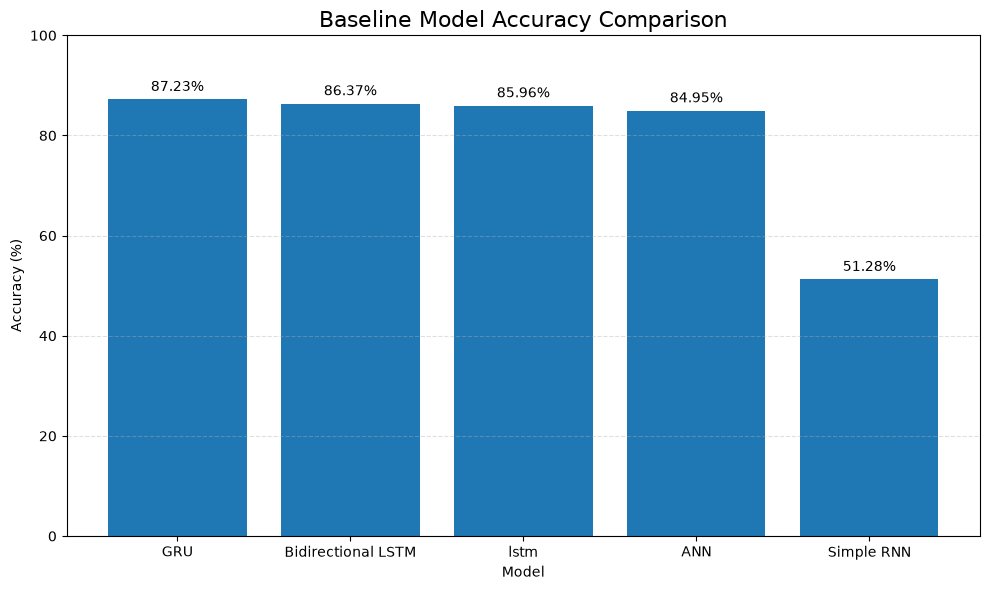

In [12]:
plt.figure(figsize=(10, 6))

bars = plt.bar(baseline_result["Model"], baseline_result["Accuracy (%)"])
plt.title("Baseline Model Accuracy Comparison", fontsize=16)
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add accuracy values
for bar, value in zip(bars, baseline_result["Accuracy (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("phase7_results/baseline_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

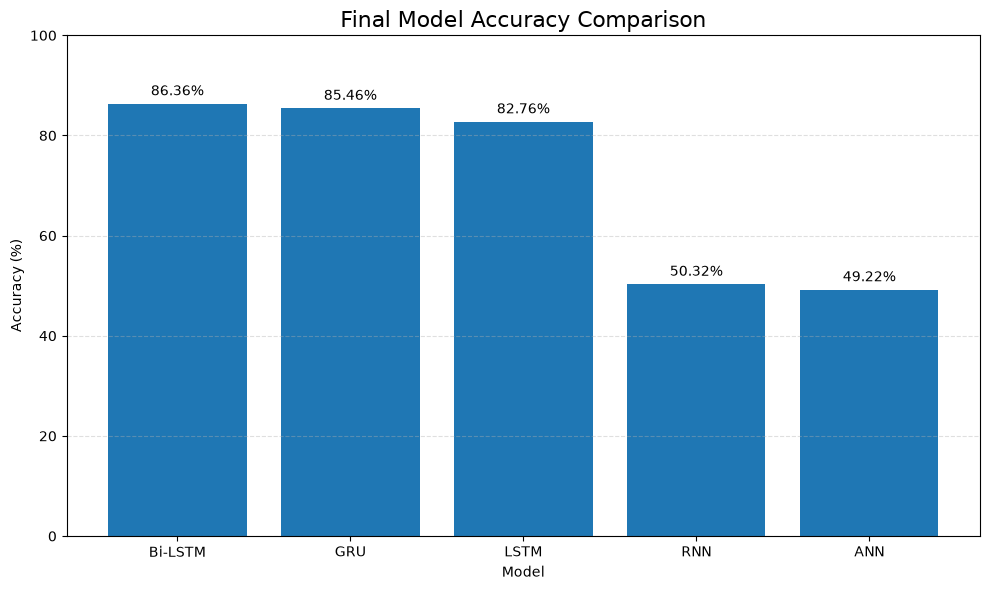

In [13]:
final_result["Accuracy (%)"] = (final_result["Accuracy"] * 100)

plt.figure(figsize=(10, 6))
bars = plt.bar(final_result["Model"], final_result["Accuracy (%)"])
plt.title("Final Model Accuracy Comparison", fontsize=16)
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Show only model name before first space
plt.xticks(range(len(final_result)), final_result["Model"].str.split().str[0])

# Add accuracy values
for bar, value in zip(bars, final_result["Accuracy (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("phase7_results/final_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# Phase 8 – Model Interpretation

### Important Words

The model learned sentiment-related patterns from the processed reviews. Positive words such as excellent, wonderful, amazing, great, enjoyable generally contributed to positive predictions, while words such as bad, boring, worst, terrible, waste contributed to negative predictions.

### Correctly Classified Reviews

Most reviews were classified correctly, showing that the selected GRU model successfully learned useful sentiment patterns from the IMDb dataset.

### Misclassified Reviews

Some reviews were incorrectly classified because they contain mixed opinions, sarcasm, context-dependent expressions, or ambiguous language. For example, a review may contain both positive and negative words.

### Positive vs Negative Language Patterns
Positive: excellent, amazing, enjoyable, wonderful, brilliant, great

Negative: terrible, boring, worst, poor, disappointing, waste

The model uses these learned language patterns to distinguish between positive and negative reviews.

### Model Limitations

Difficulty understanding sarcasm and irony

Difficulty with mixed sentiment

Limited understanding of deeper context

Performance depends on the training dataset

Long reviews may contain conflicting sentiment signals

### Effect of Preprocessing and Optimization

Text preprocessing such as cleaning, label encoding, tokenization, and padding converted raw reviews into a suitable format for deep learning. Optimization techniques such as learning-rate tuning, batch-size tuning, ReduceLR, Dropout, and EarlyStopping improved model performance.

The Bi-LSTM model achieved the best overall test performance, obtaining 86.36% accuracy and 89.493% F1-score.